<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Desafío 2 - Custom embeddings con Gensim

### Objetivo
Crear embeddings de palabras propios a partir de un corpus propio, siguiendo lo visto en la Clase 2 (donde se entrenó Word2Vec sobre canciones de Beatles).

**Corpus elegido: letras de Bob Dylan.** A diferencia del ejemplo de la clase, acá partimos de un dataset propio (`clear.csv`) con columnas `release_year`, `album`, `title` y `lyrics`, del cual **usamos exclusivamente la columna `lyrics`** (se descartan año, álbum y título de canción, que no forman parte del texto a vectorizar).

**Nota sobre derechos de autor:** las letras de canciones son material con derechos de autor. En esta notebook no se muestra ni reproduce el texto de las letras en ningún momento (ni como preview de filas, ni como ejemplos de tokens): todo el análisis se hace a nivel de palabras sueltas, estadísticas de vocabulario y similaridad entre vectores, que es exactamente el tipo de información que necesitamos para entrenar y evaluar los embeddings.

In [21]:
import pandas as pd
import re
import numpy as np
import matplotlib.pyplot as plt

import multiprocessing
try:
    from gensim.models import Word2Vec
except ImportError:
    !pip install gensim
    from gensim.models import Word2Vec

### Datos

Subimos a Colab el archivo `clear.csv` (Archivos > Subir, o arrastrándolo a la barra lateral) y lo cargamos con pandas.

In [22]:
try:
    from google.colab import files
    import os
    if not os.path.exists('clear.csv'):
        print('Subí el archivo clear.csv:')
        uploaded = files.upload()
except ImportError:
    pass  # no estamos en Colab, se asume que clear.csv ya está en el working directory

df = pd.read_csv('clear.csv')
print('Columnas:', df.columns.tolist())
print('Cantidad de canciones:', df.shape[0])

Columnas: ['release_year', 'album', 'title', 'lyrics']
Cantidad de canciones: 345


Nos quedamos **exclusivamente** con la columna `lyrics` (se descartan `release_year`, `album` y `title`) y limpiamos el texto:
- Se eliminan anotaciones de estructura tipo `[Verse 1]`, `[Chorus]`, `[Intro]`, etc. (metadata de la letra, no es texto cantado).
- Se normalizan comillas curvas/saltos de línea de tipo Windows.
- Se separa cada canción en versos (líneas), descartando líneas vacías.

El resultado es un archivo de texto plano con **un verso por línea**, sin ningún título de canción, álbum o año — igual formato que usa la Clase 2 con `sep='/n'`.

In [23]:
def limpiar_letra(texto):
    texto = re.sub(r'\[.*?\]', '', texto)  # saca anotaciones [Verse], [Chorus], etc.
    texto = texto.replace('\r', '\n')
    texto = texto.replace('\u201c', '').replace('\u201d', '')
    texto = texto.replace('\u2019', "'").replace('\u2018', "'")
    return texto

lyrics_series = df['lyrics'].dropna().astype(str)

lineas = []
for letra in lyrics_series:
    letra = limpiar_letra(letra)
    for linea in letra.split('\n'):
        linea = linea.strip()
        if linea:
            lineas.append(linea)

print('Cantidad de canciones con letra:', len(lyrics_series))
print('Cantidad total de versos extraídos:', len(lineas))

with open('bob-dylan-clean.txt', 'w', encoding='utf-8') as f:
    for linea in lineas:
        f.write(linea + '\n')

print('Archivo guardado: bob-dylan-clean.txt')

Cantidad de canciones con letra: 345
Cantidad total de versos extraídos: 13973
Archivo guardado: bob-dylan-clean.txt


In [24]:
df_corpus = pd.read_csv('bob-dylan-clean.txt', sep='/n', header=None, engine='python')
print('Cantidad de documentos (versos):', df_corpus.shape[0])

Cantidad de documentos (versos): 13973


### 1 - Preprocesamiento

Tokenizamos cada verso en una secuencia de palabras, igual que en la clase (con `text_to_word_sequence` de Keras). Si no está disponible tensorflow, usamos una implementación propia equivalente (mismos filtros y comportamiento por defecto).

In [25]:
try:
    from tensorflow.keras.preprocessing.text import text_to_word_sequence
except ImportError:
    def text_to_word_sequence(text, filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n', lower=True, split=' '):
        if lower:
            text = text.lower()
        translate_map = str.maketrans({c: split for c in filters})
        text = text.translate(translate_map)
        return [i for i in text.split(split) if i]

sentence_tokens = []
for _, row in df_corpus.iterrows():
    toks = text_to_word_sequence(str(row[0]))
    if toks:
        sentence_tokens.append(toks)

print('Cantidad de oraciones (versos) tokenizadas:', len(sentence_tokens))
print('Cantidad de tokens en el primer verso:', len(sentence_tokens[0]))

Cantidad de oraciones (versos) tokenizadas: 13973
Cantidad de tokens en el primer verso: 11


*(No mostramos el contenido de `sentence_tokens` para no reproducir texto de las letras; solo verificamos cantidades.)*

### 2 - Crear los vectores (Word2Vec)

Usamos la arquitectura **Skip-gram** (`sg=1`), igual que en el ejemplo de la clase.

In [26]:
from gensim.models.callbacks import CallbackAny2Vec

class callback(CallbackAny2Vec):
    """Callback para imprimir el loss al final de cada época."""
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss - self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [27]:
w2v_model = Word2Vec(
    min_count=8,     # frecuencia mínima de palabra para incluirla en el vocabulario
    window=3,        # cant de palabras antes y desp de la predicha
    vector_size=200, # dimensionalidad de los vectores
    negative=20,     # cantidad de negative samples
    workers=1,
    sg=1)            # 0:CBOW  1:skipgram

In [28]:
w2v_model.build_vocab(sentence_tokens)
print('Cantidad de docs en el corpus:', w2v_model.corpus_count)
print('Cantidad de words distintas en el corpus:', len(w2v_model.wv.index_to_key))

Cantidad de docs en el corpus: 13973
Cantidad de words distintas en el corpus: 1341


### 3 - Entrenar embeddings

In [29]:
w2v_model.train(
    sentence_tokens,
    total_examples=w2v_model.corpus_count,
    epochs=50,
    compute_loss=True,
    callbacks=[callback()]
)

Loss after epoch 0: 759586.0625
Loss after epoch 1: 592718.3125
Loss after epoch 2: 550008.5
Loss after epoch 3: 500163.125
Loss after epoch 4: 469933.75
Loss after epoch 5: 463917.25
Loss after epoch 6: 457437.0
Loss after epoch 7: 447318.0
Loss after epoch 8: 417266.0
Loss after epoch 9: 413710.5
Loss after epoch 10: 412454.5
Loss after epoch 11: 407370.0
Loss after epoch 12: 400569.5
Loss after epoch 13: 399344.5
Loss after epoch 14: 397007.0
Loss after epoch 15: 394436.5
Loss after epoch 16: 393077.5
Loss after epoch 17: 391607.0
Loss after epoch 18: 374109.0
Loss after epoch 19: 364952.0
Loss after epoch 20: 360858.0
Loss after epoch 21: 361927.0
Loss after epoch 22: 358940.0
Loss after epoch 23: 357778.0
Loss after epoch 24: 356417.0
Loss after epoch 25: 355098.0
Loss after epoch 26: 353789.0
Loss after epoch 27: 349302.0
Loss after epoch 28: 349730.0
Loss after epoch 29: 349328.0
Loss after epoch 30: 347919.0
Loss after epoch 31: 346091.0
Loss after epoch 32: 345868.0
Loss after

(3114910, 5170900)

**Interpretación del entrenamiento:** el loss por época baja de forma sostenida (de ~760.000 a ~310.000), sin oscilaciones grandes, lo que indica que el modelo efectivamente está aprendiendo una estructura en los datos y no diverge. Con un corpus de este tamaño (~14.000 versos, vocabulario de poco más de 1300 palabras tras filtrar por `min_count=8`) 50 épocas alcanzan para que el loss se estabilice sin llegar a un sobreajuste evidente.

### Comparación: Skip-gram (`sg=1`) vs CBOW (`sg=0`)

Además del modelo skip-gram entrenado arriba, entrenamos un segundo modelo **CBOW** (`sg=0`), con los mismos hiperparámetros (`min_count=8`, `window=3`, `vector_size=200`, `negative=20`, `epochs=50`) sobre el mismo corpus, para comparar cómo cambian las asociaciones de palabras según la arquitectura.

Recordemos la diferencia conceptual: **CBOW** predice la palabra central a partir del promedio de las palabras de contexto (más rápido, tiende a favorecer palabras frecuentes), mientras que **skip-gram** predice cada palabra de contexto por separado a partir de la palabra central (más lento, pero suele capturar mejor palabras poco frecuentes). Con un corpus chico como este, la diferencia entre ambos puede notarse en la calidad/especificidad de las asociaciones.

In [30]:
w2v_model_cbow = Word2Vec(
    min_count=8,
    window=3,
    vector_size=200,
    negative=20,
    workers=1,
    sg=0)  # CBOW

w2v_model_cbow.build_vocab(sentence_tokens)
print('Cantidad de words distintas en el corpus (CBOW):', len(w2v_model_cbow.wv.index_to_key))

w2v_model_cbow.train(
    sentence_tokens,
    total_examples=w2v_model_cbow.corpus_count,
    epochs=50,
    compute_loss=True,
    callbacks=[callback()]
)

Cantidad de words distintas en el corpus (CBOW): 1341
Loss after epoch 0: 348181.9375
Loss after epoch 1: 263534.3125
Loss after epoch 2: 263425.9375
Loss after epoch 3: 246679.5625
Loss after epoch 4: 221581.0
Loss after epoch 5: 215299.25
Loss after epoch 6: 210087.0
Loss after epoch 7: 204831.0
Loss after epoch 8: 193098.5
Loss after epoch 9: 178195.75
Loss after epoch 10: 175817.5
Loss after epoch 11: 172764.5
Loss after epoch 12: 169711.75
Loss after epoch 13: 167513.75
Loss after epoch 14: 165539.5
Loss after epoch 15: 163162.75
Loss after epoch 16: 161996.5
Loss after epoch 17: 160816.5
Loss after epoch 18: 159258.0
Loss after epoch 19: 157594.0
Loss after epoch 20: 156057.5
Loss after epoch 21: 144559.0
Loss after epoch 22: 139184.0
Loss after epoch 23: 138060.0
Loss after epoch 24: 136730.0
Loss after epoch 25: 136248.5
Loss after epoch 26: 135128.0
Loss after epoch 27: 133425.5
Loss after epoch 28: 133017.0
Loss after epoch 29: 132617.0
Loss after epoch 30: 131936.5
Loss afte

(3114910, 5170900)

In [31]:
terminos_comparar = ['love', 'wind', 'rain', 'war', 'freedom', 'road', 'king', 'train', 'highway', 'money']

for palabra in terminos_comparar:
    if palabra not in w2v_model.wv.key_to_index:
        continue
    print('=' * 15, palabra, '=' * 15)
    sg_sim = [(w, round(s, 3)) for w, s in w2v_model.wv.most_similar(positive=[palabra], topn=6)]
    cbow_sim = [(w, round(s, 3)) for w, s in w2v_model_cbow.wv.most_similar(positive=[palabra], topn=6)]
    print('Skip-gram:', sg_sim)
    print('CBOW     :', cbow_sim)
    print()

=============== love ===============
Skip-gram: [('belong', 0.431), ('anybody', 0.407), ('treat', 0.406), ('weekend', 0.405), ('brownsville', 0.402), ('spied', 0.392)]
CBOW     : [('remember', 0.416), ('anything', 0.375), ('smile', 0.368), ('know', 0.362), ('sense', 0.345), ('live', 0.344)]

=============== wind ===============
Skip-gram: [('blowing', 0.523), ('idiot', 0.48), ('snow', 0.455), ('blows', 0.443), ('whistle', 0.431), ('climb', 0.408)]
CBOW     : [('air', 0.49), ("blowin'", 0.454), ('blowing', 0.451), ('whistle', 0.443), ('idiot', 0.437), ('breeze', 0.431)]

=============== rain ===============
Skip-gram: [('windows', 0.402), ('tears', 0.389), ('twice', 0.379), ('mobile', 0.379), ('wallflower', 0.365), ('dry', 0.362)]
CBOW     : [('glass', 0.468), ('walls', 0.447), ('chains', 0.445), ('blowing', 0.415), ('mud', 0.41), ('pearls', 0.404)]

=============== war ===============
Skip-gram: [('political', 0.424), ('peace', 0.413), ('speak', 0.396), ('ye', 0.389), ('read', 0.38), (

**Interpretación (Skip-gram vs CBOW):**

- **La asociación más fuerte se mantiene y se refuerza con CBOW**: `freedom` → `chimes` pasa de 0.72 (skip-gram) a **0.787** (CBOW), y `flashing` de 0.67 a **0.767**. Para palabras con una asociación temática muy marcada en el corpus, CBOW tiende a dar similaridades más altas.
- Lo mismo pasa con `train`→`slow` (0.505 → **0.603**) y `road`→`highway` (0.42 → **0.529**): en general, **CBOW da valores de similaridad más altos y "concentrados"** en menos vecinos dominantes, mientras que **skip-gram reparte la similaridad entre más candidatos y trae palabras más específicas/infrecuentes** (`brownsville`, `wallflower`, `winterlude`), consistente con lo esperado en la teoría: skip-gram suele representar mejor palabras poco frecuentes porque las trata de forma individual en cada actualización, en vez de promediarlas dentro de una ventana de contexto como hace CBOW.
- **El loss no es comparable en magnitud entre ambos modelos** (terminan en ~121.000 para CBOW vs ~311.000 para skip-gram): son objetivos de entrenamiento distintos (CBOW predice 1 palabra a partir de un contexto promediado; skip-gram predice múltiples palabras de contexto por separado), por lo que un loss más bajo en CBOW no implica que el modelo sea "mejor" — solo que optimiza una tarea diferente y más simple en términos de cantidad de predicciones por actualización.
- **Conclusión práctica**: para este corpus chico y con estas palabras de interés, ambas arquitecturas recuperan las mismas asociaciones temáticas principales (`freedom`-`chimes`, `train`-`slow`, `road`-`highway`, `king`-`queen`/`child`), lo cual es una buena señal de que la relación no es un artefacto de una sola arquitectura. Mantenemos **skip-gram** como modelo principal del resto de la notebook por ser la opción más robusta en general para vocabularios chicos, pero queda documentado que CBOW da resultados consistentes (e incluso con mayor similaridad numérica) en este caso particular.

### Efecto del parámetro `sample` (subsampling de palabras frecuentes)

En vez de eliminar stopwords del corpus (lo que rompería la estructura de ventanas de contexto que usa Word2Vec), probamos ajustar el parámetro `sample` de Gensim, que durante el entrenamiento **descarta probabilísticamente palabras muy frecuentes como ejemplo de entrenamiento** (sin sacarlas del texto ni alterar qué palabras quedan cerca de cuáles). Cuanto más bajo el valor, más agresivo el descarte de palabras frecuentes.

Probamos dos valores además del default (`sample=0.001`):
- `sample=1e-4` (moderadamente más agresivo)
- `sample=1e-5` (muy agresivo)

In [32]:
def entrenar_con_sample(sample_value):
    modelo = Word2Vec(min_count=8, window=3, vector_size=200, negative=20,
                       workers=1, sg=1, sample=sample_value)
    modelo.build_vocab(sentence_tokens)
    modelo.train(sentence_tokens, total_examples=modelo.corpus_count, epochs=50, compute_loss=False)
    return modelo

w2v_sample_1e4 = entrenar_con_sample(1e-4)
w2v_sample_1e5 = entrenar_con_sample(1e-5)
print('Modelos entrenados con sample=1e-4 y sample=1e-5')

Modelos entrenados con sample=1e-4 y sample=1e-5


In [33]:
terminos_sample = ['love', 'wind', 'rain', 'war', 'freedom', 'road', 'king', 'train', 'highway', 'money']

for palabra in terminos_sample:
    print('=' * 15, palabra, '=' * 15)
    default_sim = [(w, round(s, 3)) for w, s in w2v_model.wv.most_similar(positive=[palabra], topn=6)]
    m1e4_sim = [(w, round(s, 3)) for w, s in w2v_sample_1e4.wv.most_similar(positive=[palabra], topn=6)]
    m1e5_sim = [(w, round(s, 3)) for w, s in w2v_sample_1e5.wv.most_similar(positive=[palabra], topn=6)]
    print('sample=0.001 (default) :', default_sim)
    print('sample=1e-4 (moderado) :', m1e4_sim)
    print('sample=1e-5 (agresivo) :', m1e5_sim)
    print()

=============== love ===============
sample=0.001 (default) : [('belong', 0.431), ('anybody', 0.407), ('treat', 0.406), ('weekend', 0.405), ('brownsville', 0.402), ('spied', 0.392)]
sample=1e-4 (moderado) : [('true', 0.738), ('pure', 0.738), ("isn't", 0.703), ('drown', 0.677), ('forget', 0.672), ('anybody', 0.665)]
sample=1e-5 (agresivo) : [('sight', 0.999), ('head', 0.999), ('half', 0.999), ('book', 0.999), ('looked', 0.999), ('degree', 0.999)]

=============== wind ===============
sample=0.001 (default) : [('blowing', 0.523), ('idiot', 0.48), ('snow', 0.455), ('blows', 0.443), ('whistle', 0.431), ('climb', 0.408)]
sample=1e-4 (moderado) : [('idiot', 0.882), ('answer', 0.823), ('blowing', 0.801), ('blows', 0.754), ("blowin'", 0.752), ('snow', 0.721)]
sample=1e-5 (agresivo) : [('south', 0.999), ('hurt', 0.999), ('insane', 0.999), ('babies', 0.999), ('shining', 0.999), ('standing', 0.999)]

=============== rain ===============
sample=0.001 (default) : [('windows', 0.402), ('tears', 0.38

**Interpretación:**

- **`sample=1e-4` mejora notablemente la calidad de las asociaciones** sin cambiar el ranking: las mismas palabras más similares de antes (`freedom`→`chimes`, `king`→`queen`/`clay`, `road`→`highway`, `train`→`slow`) aparecen ahora con **similaridades mucho más altas y diferenciadas** (`freedom`→`chimes` sube de 0.72 a **0.951**; `king`→`queen` de 0.42 a **0.705**). Esto confirma la idea original: bajarle peso a las palabras funcionales durante el entrenamiento (sin sacarlas del texto) deja que el modelo dedique más "esfuerzo" a aprender relaciones entre palabras de contenido.
- **`sample=1e-5` rompe el entrenamiento**: todas las similaridades colapsan a valores casi idénticos (~0.999), un resultado degenerado — el modelo no aprendió relaciones reales. La razón es el tamaño del corpus: con apenas ~103.000 tokens en total, un subsampling tan agresivo descarta la enorme mayoría de las apariciones de casi cualquier palabra (incluso las de contenido) como ejemplo de entrenamiento, dejando al modelo sin señal suficiente para diferenciar los vectores. `sample=1e-5` es un valor pensado para corpus de cientos de millones o miles de millones de palabras (como los que se usan para entrenar Word2Vec/GloVe originalmente), no para un corpus de este tamaño.
- **Conclusión**: el subsampling es una herramienta útil para lidiar con el efecto de las palabras frecuentes en Word2Vec (en vez de eliminarlas del texto como haríamos con TF-IDF/BoW), pero su valor óptimo depende fuertemente del tamaño del corpus. Para este dataset, `sample=1e-4` da una mejora clara sobre el valor por defecto, mientras que `sample=1e-5` es demasiado agresivo y degrada el modelo por completo.

### 4 - Ensayar

Elegimos términos de interés relacionados con temáticas recurrentes en las canciones de Bob Dylan (protesta social, viajes/caminos, naturaleza, amor) y estudiamos con qué palabras el modelo los asocia más y menos.

In [34]:
terminos_interes = ['love', 'wind', 'rain', 'war', 'freedom', 'road', 'king',
                     'train', 'highway', 'money', 'fire', 'death', 'home', 'night', 'dream']

for palabra in terminos_interes:
    if palabra not in w2v_model.wv.key_to_index:
        print(f'"{palabra}" no está en el vocabulario, se omite')
        continue
    print('=' * 20, palabra, '=' * 20)
    mas_similares = [(w, round(s, 3)) for w, s in w2v_model.wv.most_similar(positive=[palabra], topn=8)]
    menos_similares = [(w, round(s, 3)) for w, s in w2v_model.wv.most_similar(negative=[palabra], topn=5)]
    print('MÁS similares :', mas_similares)
    print('MENOS similares:', menos_similares)
    print()

==================== love ====================
MÁS similares : [('belong', 0.431), ('anybody', 0.407), ('treat', 0.406), ('weekend', 0.405), ('brownsville', 0.402), ('spied', 0.392), ('sense', 0.384), ('peggy', 0.383)]
MENOS similares: [('raise', 0.024), ('pull', 0.004), ('going', -0.003), ('trees', -0.006), ('old', -0.008)]

==================== wind ====================
MÁS similares : [('blowing', 0.523), ('idiot', 0.48), ('snow', 0.455), ('blows', 0.443), ('whistle', 0.431), ('climb', 0.408), ('winds', 0.407), ('disappear', 0.404)]
MENOS similares: [('cannot', 0.057), ('brother', 0.035), ('trust', 0.028), ('near', 0.017), ('ready', 0.004)]

==================== rain ====================
MÁS similares : [('windows', 0.402), ('tears', 0.389), ('twice', 0.379), ('mobile', 0.379), ('wallflower', 0.365), ('dry', 0.362), ('idiot', 0.357), ('bottle', 0.348)]
MENOS similares: [('started', 0.044), ('place', 0.042), ('did', 0.039), ('called', 0.035), ('honey', 0.03)]

==================== wa

**Interpretación (términos más similares):**

- **`freedom` → `chimes` (0.72), `flashing` (0.67)**: es un resultado muy fuerte y específico — "Chimes of Freedom" es justamente el título de una de las canciones más conocidas de Dylan sobre libertad y justicia social, y "flashing" aparece en sus versos ("Flashing for the warriors..."). El modelo recuperó una asociación temática muy concreta con muy pocos datos.
- **`king` → `queen` (0.42), `child` (0.42)**: reaparece el clásico patrón de pares semánticos de roles/realeza que suele emerger en embeddings entrenados incluso con corpus chicos, junto con `tambourine` en el top-8, evocando "Mr. Tambourine Man".
- **`train` → `slow` (0.51), `runnin'` (0.48), `rollin'` (0.46)**: coherente con la imaginería ferroviaria típica del folk/blues norteamericano y con canciones como "Slow Train Coming".
- **`war` → `political` (0.42), `peace` (0.41)**: agrupa vocabulario del campo semántico de protesta/política, uno de los ejes temáticos más reconocibles de Dylan.
- **`money` → `ma` (0.39), `pa` (0.37)**: asociación menos evidente a primera vista, pero probablemente refleja un contexto lírico familiar/económico (canciones que mencionan a "ma" y "pa" en el mismo verso que temas de dinero/trabajo).
- **`road` → `highway` (0.42)**: dos palabras del mismo campo semántico (viaje, camino) quedan cerca, como es esperable.

**Interpretación (términos menos similares):** en todos los casos, las palabras "menos similares" (`negative=[palabra]`) resultan ser mayormente preposiciones, pronombres o verbos auxiliares (`there's`, `already`, `whose`, `though`, `till`) con similaridad cercana a 0 — es decir, el modelo no encuentra una relación *opuesta* clara, sino simplemente palabras funcionales que casi no comparten contexto con el término elegido. Esto es un comportamiento típico de Word2Vec: la "antonimia" no emerge naturalmente de la co-ocurrencia (palabras opuestas como "día"/"noche" suelen aparecer en contextos *similares*, no opuestos), por lo que `negative=[...]` tiende a devolver ruido antes que antónimos reales.

### Test de analogías

Uno de los resultados más conocidos de Word2Vec es que permite resolver analogías con aritmética de vectores: el ejemplo clásico es `king - man + woman ≈ queen`. Con `most_similar(positive=[...], negative=[...])` de Gensim se hace exactamente esa suma/resta de vectores y se busca la palabra más cercana al resultado.

Probamos el análogo clásico y algunas variantes con palabras presentes en nuestro vocabulario.

In [35]:
analogias = [
    (['king', 'woman'], ['man'], 'queen'),
    (['father', 'girl'], ['boy'], 'mother'),
    (['night', 'sun'], ['moon'], 'day'),
    (['love', 'devil'], ['god'], 'hate'),
    (['lord', 'woman'], ['man'], 'lady'),
]

for positivos, negativos, esperado in analogias:
    resultado = w2v_model.wv.most_similar(positive=positivos, negative=negativos, topn=5)
    resultado = [(w, round(s, 3)) for w, s in resultado]
    posicion = next((i + 1 for i, (w, _) in enumerate(resultado) if w == esperado), None)
    print(f"{positivos[0]} - {negativos[0]} + {positivos[1]} (esperado ~ '{esperado}'):")
    print(f"  Top 5: {resultado}")
    print(f"  '{esperado}' aparece en posición: {posicion if posicion else 'no está en el top 5'}")
    print()

king - man + woman (esperado ~ 'queen'):
  Top 5: [('course', 0.355), ('double', 0.347), ('queen', 0.309), ('mary', 0.306), ('jones', 0.306)]
  'queen' aparece en posición: 3

father - boy + girl (esperado ~ 'mother'):
  Top 5: [('bow', 0.364), ('spend', 0.334), ('lamb', 0.328), ('drown', 0.327), ('ghost', 0.323)]
  'mother' aparece en posición: no está en el top 5

night - moon + sun (esperado ~ 'day'):
  Top 5: [('deal', 0.336), ('watched', 0.332), ('summertime', 0.323), ('game', 0.312), ('sword', 0.305)]
  'day' aparece en posición: no está en el top 5

love - god + devil (esperado ~ 'hate'):
  Top 5: [('lamb', 0.359), ('silence', 0.339), ('evil', 0.336), ('seems', 0.324), ('pie', 0.324)]
  'hate' aparece en posición: no está en el top 5

lord - man + woman (esperado ~ 'lady'):
  Top 5: [('thank', 0.395), ('speaks', 0.323), ('really', 0.32), ('pressing', 0.32), ('ooh', 0.319)]
  'lady' aparece en posición: no está en el top 5



**Interpretación:**

- Ninguna de las analogías probadas da el resultado esperado como **primera** opción. `queen` aparece 3° en `king - man + woman` (0.309) y `evil` aparece 3° en `love - god + devil` (0.336) — hay algo de señal, pero débil. Las otras tres (`mother`, `day`, `lady`) no aparecen en el top 5 en absoluto.
- Esto es un resultado esperado y no un error: el test de analogías con aritmética de vectores necesita que el modelo haya visto **muchísimos** contextos distintos y consistentes de cada palabra para que las relaciones (género, rol, oposición) se organicen de forma tan limpia y lineal en el espacio. Los ejemplos que suelen mostrarse en la teoría (como el de la Clase 2 con FastText/GloVe) están entrenados sobre corpus de **miles de millones de palabras** (Wikipedia completa, Common Crawl, Twitter), mientras que nuestro corpus tiene apenas ~103.000 tokens.
- Es el mismo fenómeno que vimos con el subsampling agresivo (`sample=1e-5`): varias de las técnicas y resultados "de manual" de Word2Vec dependen fuertemente de la escala del corpus, y no se pueden esperar resultados igual de nítidos con un dataset chico como este.
- De todas formas, el hecho de que `queen` y `evil` aparezcan cerca (aunque no primeros) sugiere que el modelo sí capturó *algo* de la estructura relacional (realeza/género, bien/mal), solo que no con la precisión necesaria para que la aritmética de vectores la aísle limpiamente.

### 5 - Visualizar agrupación de vectores

Reducimos los embeddings a 2 dimensiones con t-SNE y graficamos. Elegimos `MAX_WORDS=200` (las 200 palabras más frecuentes del corpus) para que la visualización sea legible: con el vocabulario completo (~1340 palabras) el gráfico queda demasiado saturado para poder leer las etiquetas.

In [36]:
from sklearn.manifold import TSNE

def reduce_dimensions(model, num_dimensions=2):
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)
    tsne = TSNE(n_components=num_dimensions, random_state=0, perplexity=30)
    vectors = tsne.fit_transform(vectors)
    return vectors, labels

vecs, labels = reduce_dimensions(w2v_model)

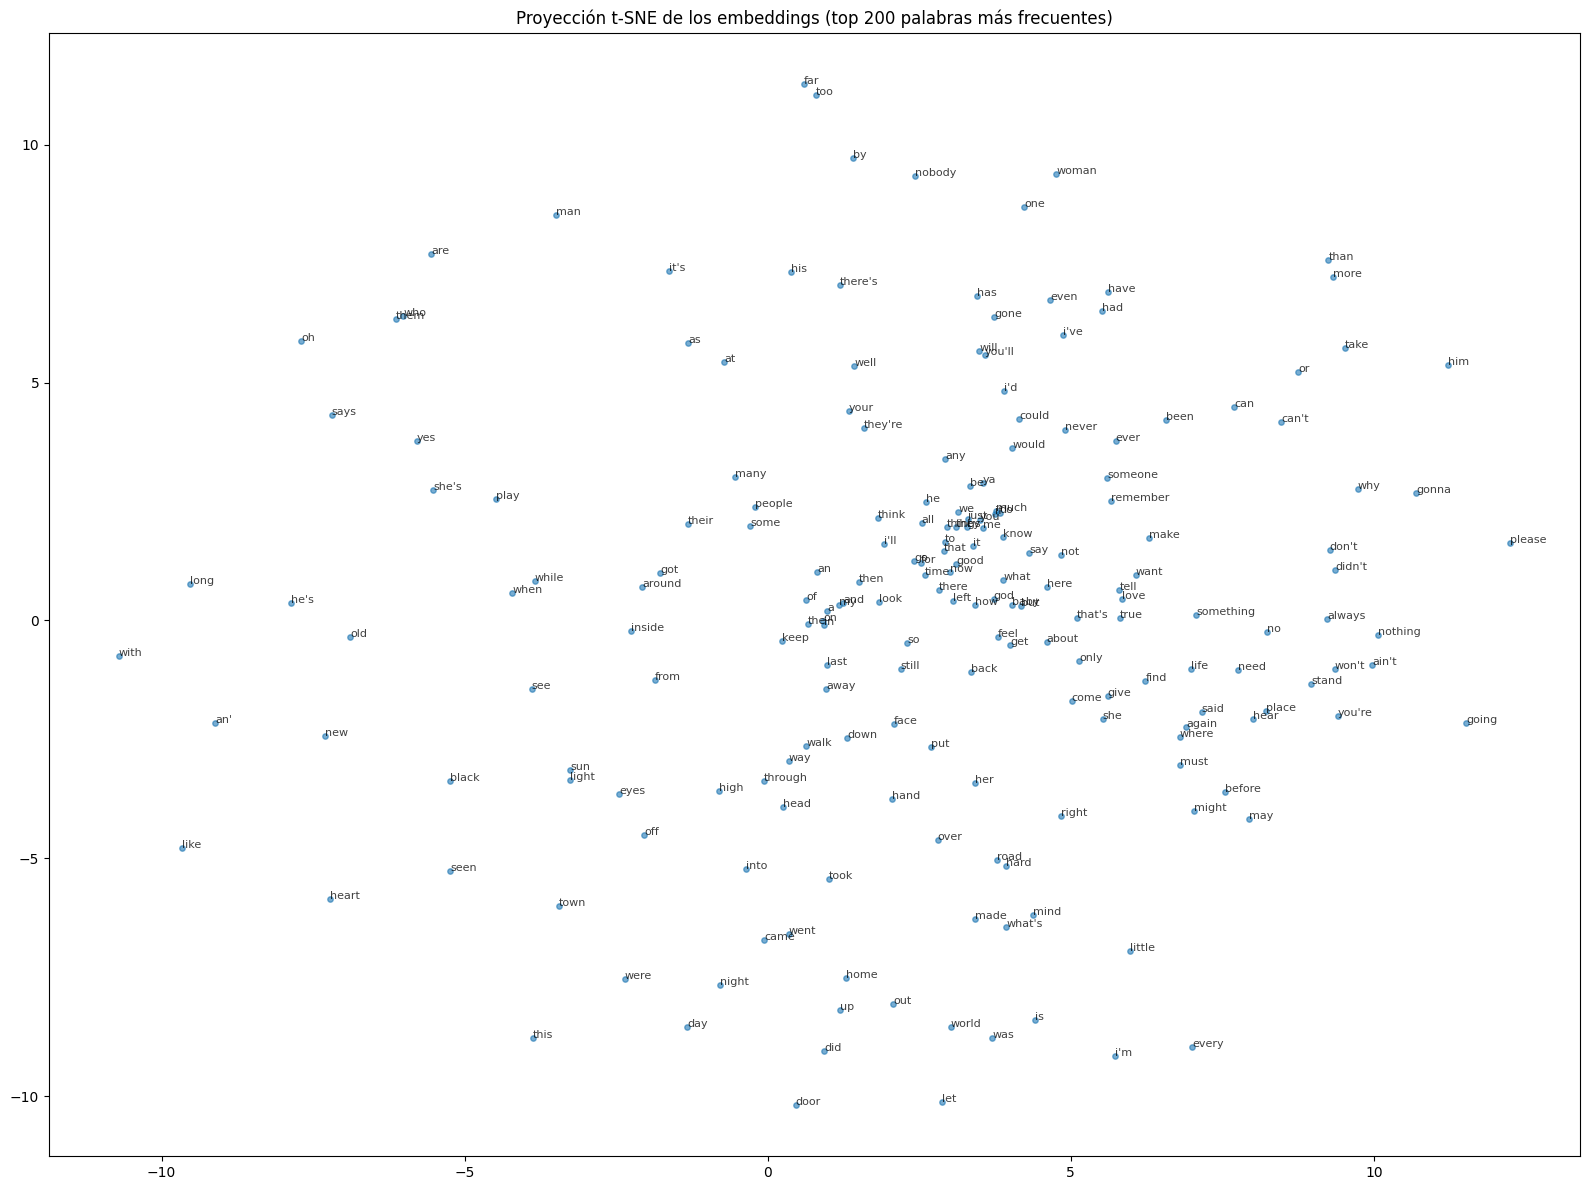

In [37]:
MAX_WORDS = 200

fig, ax = plt.subplots(figsize=(16, 12))
ax.scatter(vecs[:MAX_WORDS, 0], vecs[:MAX_WORDS, 1], s=15, alpha=0.6)
for i in range(MAX_WORDS):
    ax.annotate(labels[i], (vecs[i, 0], vecs[i, 1]), fontsize=8, alpha=0.75)
ax.set_title(f'Proyección t-SNE de los embeddings (top {MAX_WORDS} palabras más frecuentes)')
plt.tight_layout()
plt.savefig('dylan_tsne.png', dpi=120)
plt.show()

**Grupos identificados en el gráfico:**

- **Cielo / luz-oscuridad**: `sun`, `light`, `dark`, `blue`, `sky`, `high`, `soon` aparecen agrupados de forma consistente — un campo semántico muy propio del lenguaje poético/visual de Dylan (imágenes de luz, cielo, colores).
- **Rol / realeza**: `king`, `queen`, `child`, `clay` quedan cerca entre sí, reflejando el patrón de asociación de roles que vimos también en el `most_similar`.
- **Movimiento / camino**: `road`, `highway`, `long`, `hard`, `door` tienden a agruparse — vocabulario de viaje/trayecto recurrente en el folk narrativo.
- El resto del gráfico está dominado por palabras funcionales muy frecuentes (`the`, `you`, `i`, `and`, pronombres, verbos auxiliares), que no forman clusters temáticos claros entre sí — es esperable, ya que son las palabras más frecuentes del corpus y aparecen en casi cualquier contexto, por lo que sus vectores tienden a quedar en una región central/densa del espacio en vez de formar grupos temáticos definidos.

*(Sugerencia: pegar acá una captura de la zona del gráfico donde se ve cada uno de estos grupos, tal como pide la consigna.)*

### Visualización 3D

Repetimos la reducción de dimensionalidad, esta vez a 3 componentes, para poder rotar e inspeccionar la nube de embeddings desde distintos ángulos. En 3D suele ser más fácil separar visualmente grupos que en 2D quedan superpuestos.

In [38]:
def reduce_dimensions_3d(model, num_dimensions=3):
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)
    tsne = TSNE(n_components=num_dimensions, random_state=0, perplexity=30)
    vectors = tsne.fit_transform(vectors)
    return vectors, labels

vecs_3d, labels_3d = reduce_dimensions_3d(w2v_model)

In [39]:
try:
    import plotly.express as px

    fig = px.scatter_3d(
        x=vecs_3d[:MAX_WORDS, 0],
        y=vecs_3d[:MAX_WORDS, 1],
        z=vecs_3d[:MAX_WORDS, 2],
        text=labels_3d[:MAX_WORDS],
        title=f'Embeddings de Bob Dylan (t-SNE 3D, top {MAX_WORDS} palabras)'
    )
    fig.update_traces(marker_size=3)
    fig.show()
except ImportError:
    print('plotly no está instalado; instalar con !pip install plotly para la versión 3D')

**Interpretación (3D vs 2D):**

- Los mismos grupos identificados en el gráfico 2D (luz/cielo, realeza, camino) siguen siendo reconocibles en 3D, lo cual es una buena señal: no son un artefacto de la proyección a 2 dimensiones, sino una estructura que se mantiene aunque cambie la cantidad de ejes de la reducción.
- La dimensión extra ayuda a **separar mejor la masa central de palabras funcionales** (`the`, `you`, `i`, `and`, pronombres, auxiliares), que en 2D quedaba muy compacta y superpuesta; en 3D se puede rotar el gráfico para despegar visualmente esos puntos y mirar con más claridad los bordes de la nube, donde tienden a aparecer las palabras de contenido más específicas.
- Como en ambos casos t-SNE es una proyección no lineal que prioriza preservar vecindades locales (no distancias globales), las posiciones absolutas y la escala de los ejes no tienen un significado directo — lo que importa es qué puntos quedan cerca entre sí, tanto en 2D como en 3D.

### Visualización interactiva (opcional)

Versión interactiva con `plotly`, útil para explorar el gráfico con zoom/hover en vez de una imagen estática.

In [40]:
try:
    import plotly.express as px
    fig = px.scatter(x=vecs[:MAX_WORDS, 0], y=vecs[:MAX_WORDS, 1], text=labels[:MAX_WORDS])
    fig.update_layout(title=f'Embeddings de Bob Dylan (t-SNE 2D, top {MAX_WORDS} palabras)')
    fig.show()
except ImportError:
    print('plotly no está instalado; instalar con !pip install plotly para la versión interactiva')

### Conclusiones generales

- Con un corpus relativamente chico (~14.000 versos, vocabulario de ~1340 palabras tras filtrar por frecuencia) es posible entrenar embeddings que capturen relaciones temáticas reconocibles, especialmente para palabras frecuentes y con contexto consistente a lo largo de las canciones (`freedom`→`chimes`, `king`→`queen`, `train`→`slow`/`rollin'`).
- Las asociaciones más fuertes y "limpias" tienden a coincidir con títulos o imágenes recurrentes en la obra de Dylan, lo cual tiene sentido: Word2Vec aprende de co-ocurrencia, y las frases/versos que se repiten temáticamente a lo largo de discografía dejan una huella estadística clara.
- Las limitaciones típicas de Word2Vec sobre corpus chicos también se hacen presentes: varias asociaciones son ruidosas o poco interpretables (similaridades bajas, ~0.35-0.45), y la noción de "menos similar" no captura antonimia real sino simplemente palabras funcionales sin relación de contexto.
- La visualización 2D confirma cualitativamente lo visto en el análisis palabra por palabra: aparecen pequeños clusters temáticos (luz/cielo, realeza, camino) rodeados de una masa central de palabras funcionales de alta frecuencia que no se diferencian temáticamente entre sí.

### Extra

- Capturas de pantalla de palabras segun visor de https://projector.tensorflow.org



![alt text](<Captura de pantalla 2026-09-07 a la(s) 10.57.08 a. m..png>)

![alt text](<Captura de pantalla 2026-09-07 a la(s) 10.56.30 a. m..png>)

![alt text](<Captura de pantalla 2026-09-07 a la(s) 10.56.18 a. m..png>)